{'MMR': 21234.001712994923, 'CLT': 13630.722947539489, 'RH': 6177.192910806367, 'AbsCoef': 1587.5636430333336, 'Refrac': 698.5240865706241}
{'MMR': 14015.513564035024, 'CLT': 11212.383985720895, 'RH': 3569.041753503532, 'AbsCoef': 1090.3752718194821, 'Refrac': 760.2955432183304}
{'MMR': 20443.107217416244, 'CLT': 12692.569977386842, 'RH': 5144.983173084074, 'AbsCoef': 1538.3794901392816, 'Refrac': 621.3157743368005}
{'MMR': 13718.68256968259, 'CLT': 4760.881715688542, 'RH': 1421.2200174346385, 'AbsCoef': 545.0959274376861, 'Refrac': 258.4589662794869}


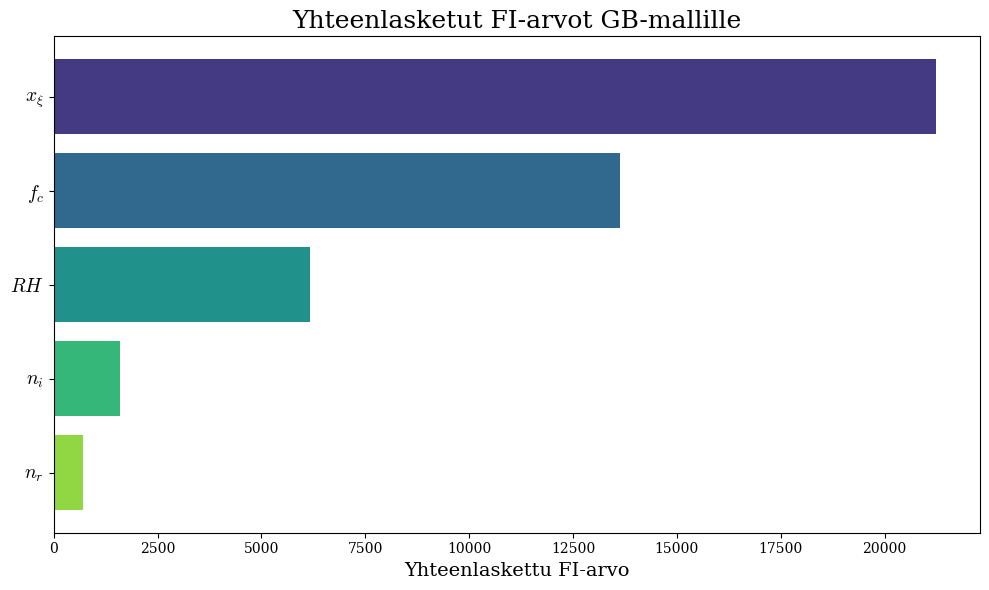

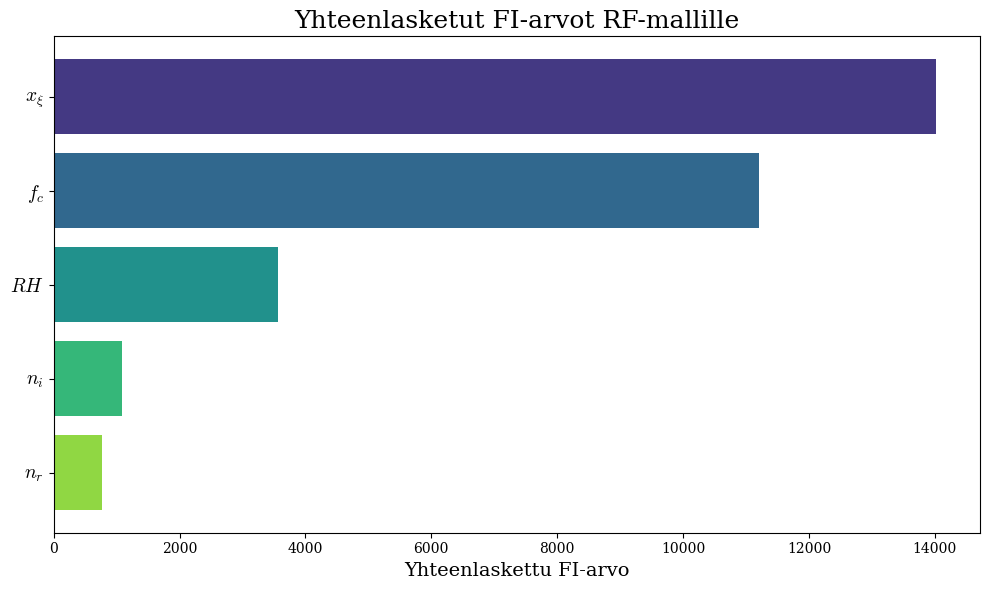

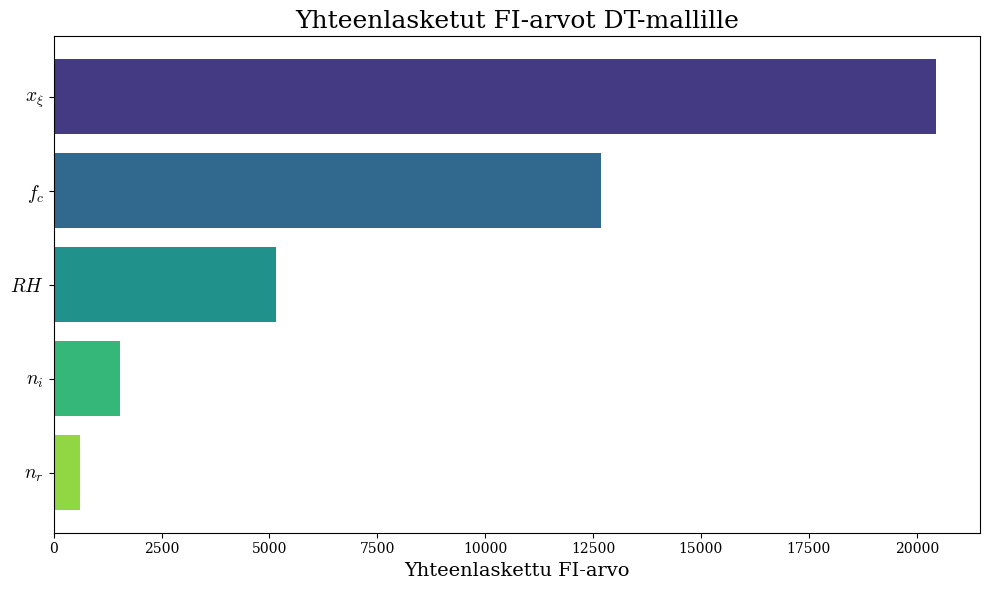

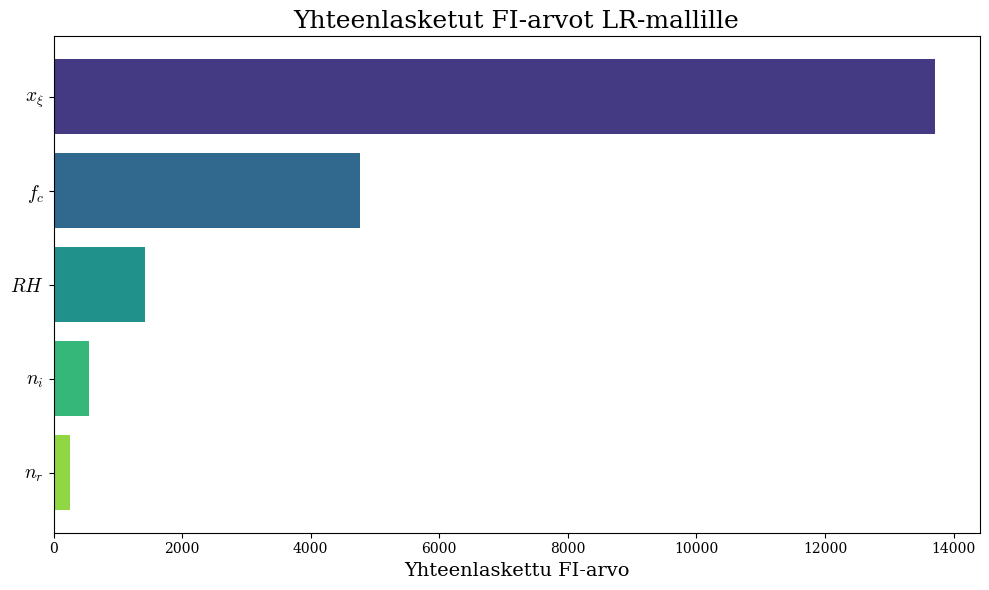

In [32]:
import numpy as np
import sys, os
import netCDF4 as nc
import matplotlib.pyplot as plt
import re
import pandas as pd
import seaborn as sns   

"""
by Atte Laakso / Aalto University

For plotting combined FI-values for domain-trained models into a barplot
"""
###################################################################################

# define parameters for this image
path = "../tools/FI_analysis/FI_results"
models = ['GB','RF','DT','LR']
domain = '1'
dataset = 'dARE_ML_data_250721'
output_dir = "../tools/FI_analysis/FI_results"
###################################################################################

md = {}
# get data for all models
for model in models:
    folder = os.path.join(path, f'data={dataset}_multimodel=True_model={model}/')
    # read the file
    with open(os.path.join(folder,f"Lower_res_{model}_metadata_{domain}_by_{domain}_grids.txt"), "r") as f:
        text = f.read()
    
    # use regex to capture "FeatureName (index x): value"
    pattern = r"(\w+) \(index \d+\): ([\d\.]+)"
    
    # find all matches
    matches = re.findall(pattern, text)
    
    # convert to dictionary {feature: value}
    features = {name: float(val) for name, val in matches}

    # print dictionary for debug and save under this model in md dictionary
    print(features)
    md[model] = features

# function for creating the barplot
def foto(feature_names,importances,modelsel):
    # map the actual names to features
    name_map = {
    "RH": r"$RH$",
    "MMR": r"$x_\xi$",
    "Refrac": r"$n_r$",
    "AbsCoef": r"$n_i$",
    "CLT": r"$f_c$",
    }
    real_names = [name_map.get(f, f) for f in feature_names]
    
    # create DataFrame with importances and their std deviation for easier handling
    feature_importances = pd.DataFrame({
        'feature': real_names,
        'importance': importances,
    }).sort_values(by='importance', ascending=False)
    
    # plot results and std as error bars
    plt.figure(figsize=(10, 6))
    plt.rcParams["text.usetex"] = False           # make sure system latex isn't required
    plt.rcParams["mathtext.fontset"] = "cm"       # Computer Modern
    plt.rcParams["font.family"] = "serif"         # ensure serif base font
    plt.rcParams["ytick.labelsize"] = 14          # control y-axis tick (feature names) size
    plt.rcParams["xtick.labelsize"] = 10          # x-axis ticks too
    plt.barh(
        feature_importances["feature"],
        feature_importances["importance"],
        color=sns.color_palette("viridis", len(feature_importances))
    )
    plt.xlabel("Yhteenlaskettu FI-arvo", fontsize=14)
    plt.title(f"Yhteenlasketut FI-arvot {modelsel}-mallille", fontsize=18)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, f"domain_FI_barplot_{modelsel}.png"))
    plt.show()
    plt.close()
    return

# make the plots for all the models
for key in md.keys():
    foto(md[key].keys(), md[key].values(),key)